In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## 图像读取

In [17]:
# imread 默认返回[h,w,c]加载是三原色图像默认返回[B,G,R]
img = cv.imread(r"F:\machine\OpenCV\t1.png")
print(type(img), img.shape)

<class 'numpy.ndarray'> (600, 510, 3)


In [4]:
img[:,:,0]

array([[  0,  29,  50, 195],
       [  0,  29,  50, 195],
       [255,  93, 255,   0],
       [255,   2, 231,  11],
       [  0,   2, 231,  11]], dtype=uint8)

In [5]:
img[:,:,1]

array([[  0,   1, 203,  69],
       [  0,   1, 203,  69],
       [255,  93, 255,   0],
       [  0, 251, 183, 255],
       [255, 251, 183, 255]], dtype=uint8)

In [7]:
img[:,:,2]

array([[  0, 255,   0, 167],
       [255, 255,   0, 167],
       [255, 174, 145, 255],
       [  0, 169, 203, 170],
       [  0, 169, 203, 170]], dtype=uint8)

In [18]:
Gray = img[:,:,1]*0.89
Gray = Gray/255
cv.imshow("image",Gray)
#让图像暂停多少秒，设置为0表示永远，按键盘任意键位结束暂停
cv.waitKey(0)
#释放所有资源
cv.destroyAllWindows()

In [19]:
cv.__version__

'4.10.0'

## 图像基础处理

In [20]:
# 第二个参数设置为0表示灰度加载，1表示加载bgr图像，默认为1，-1表示记载alpha透明通道图像
img = cv.imread(r"F:\machine\OpenCV\t1.png",1)
print(type(img), img.shape)

<class 'numpy.ndarray'> (600, 510, 3)


In [21]:
cv.imshow("image", img)
cv.waitKey(0)
cv.destroyAllWindows()

In [22]:
cv.imwrite(r"F:\machine\OpenCV\smallpeople.png", img)

True

(600, 510, 3)


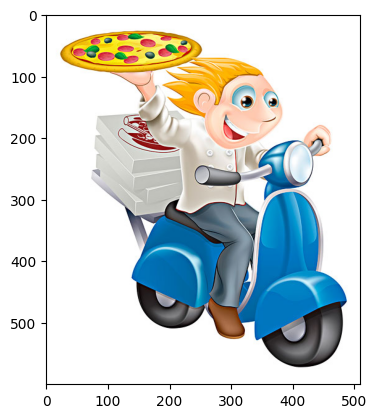

In [27]:
img = cv.imread(r"F:\machine\OpenCV\t1.png",1)
img2 = np.zeros_like(img, dtype=img.dtype)
# img2[:,:,0] = img[:,:,2]
# img2[:,:,1] = img[:,:,1]
# img2[:,:,2] = img[:,:,0]
img2 = img[:,:,::-1]
print(img2.shape)
plt.imshow(img2)
plt.show()

(600, 510)


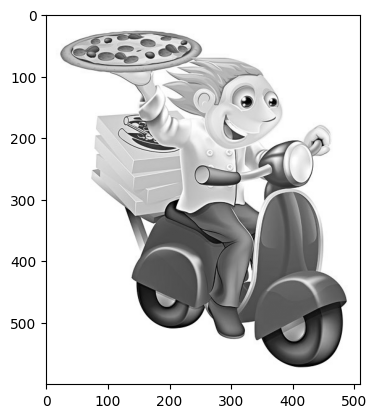

In [30]:
#显示灰度图
# img = cv.imread(r"F:\machine\OpenCV\t1.png",cv.IMREAD_GRAYSCALE)
img = cv.imread(r"F:\machine\OpenCV\t1.png",0)
print(img.shape)
plt.imshow(img, cmap="gray")
plt.show()

In [31]:
img = cv.imread(r"F:\machine\OpenCV\t1.png",1)
cv.imshow("image", np.transpose(img, (1,0,2)))
cv.waitKey(0)
cv.destroyAllWindows()

In [32]:
img = cv.imread(r"F:\machine\OpenCV\t1.png",1)
cv.imshow("image", img[200:400,100:300,:])
cv.waitKey(0)
cv.destroyAllWindows()

## 视频基本处理

In [37]:
capture = cv.VideoCapture(0)
success = capture.set(cv.CAP_PROP_FRAME_WIDTH, 880)
success = capture.set(cv.CAP_PROP_FRAME_HEIGHT, 480)
size = (int(capture.get(cv.CAP_PROP_FRAME_WIDTH)),int(capture.get(cv.CAP_PROP_FRAME_HEIGHT)))
print(size)
success, frame = capture.read()
print(type(frame), frame.shape)
# -1表示等待delay后，没有任何键盘输入
while success and cv.waitKey(1) == -1:
    cv.imshow("frame", frame)
    success, frame = capture.read()
    

#释放资源
capture.release()
cv.destroyAllWindows()

(848, 480)
<class 'numpy.ndarray'> (480, 848, 3)


In [40]:
capture = cv.VideoCapture(0)
print(capture.get(cv.CAP_PROP_FPS))
success = capture.set(cv.CAP_PROP_FRAME_WIDTH, 880)
success = capture.set(cv.CAP_PROP_FRAME_HEIGHT, 480)
size = (int(capture.get(cv.CAP_PROP_FRAME_WIDTH)),int(capture.get(cv.CAP_PROP_FRAME_HEIGHT)))
fps=15
# https://blog.csdn.net/m0_38082783/article/details/129351439
video_writer = cv.VideoWriter("v1.avi", cv.VideoWriter_fourcc("I","4","2","0"),fps,size)
num_frame = 10 * fps - 1
success, frame = capture.read()
while success and num_frame>0:
    video_writer.write(frame)
    success, frame = capture.read()
    num_frame -= 1

capture.release()
cv.destroyAllWindows()

30.0


In [41]:
capture = cv.VideoCapture("v1.avi")

success, frame = capture.read()
print(type(frame), frame.shape)
# -1表示等待delay后，没有任何键盘输入
while success and cv.waitKey(1) == -1:
    cv.imshow("frame", frame)
    success, frame = capture.read()
    

#释放资源
capture.release()
cv.destroyAllWindows()

<class 'numpy.ndarray'> (480, 848, 3)


In [42]:
capture = cv.VideoCapture("v1.avi")

success, frame = capture.read()
k=0
while success and cv.waitKey(60) == -1:
    if k % 1 == 0:
        cv.imwrite(r"F:\machine\OpenCV\v1_frame\img_{}.png".format(k), frame)
    k+=1
    success, frame = capture.read()

capture.release()
cv.destroyAllWindows()

### 基于OpenCV的基本绘画

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### 画直线

In [3]:
img = np.zeros((512, 512, 3), np.uint8)

cv.line(img, pt1=(0,0), pt2=(511, 511), color=(255,0,0), thickness=2)

cv.imshow("imge",img)
cv.waitKey(0)
cv.destroyAllWindows()

### 画矩形

In [7]:
img = np.zeros((512, 512, 3), np.uint8)
cv.rectangle(img,pt1=(5,5), pt2=(100,100),color=(0,0,255),thickness=2)
cv.rectangle(img,pt1=(5,5), pt2=(100,100),color=(0,0,255),thickness=-1)

cv.imshow("imge",img)
cv.waitKey(0)
cv.destroyAllWindows()

### 写font

In [16]:
img = np.zeros((512, 512, 3), np.uint8)
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(img, text="opencv", org=(20,300), fontFace=font, fontScale=4, color=(255,255,255), thickness=2, lineType=cv.LINE_4)
cv.line(img, pt1=(20,300), pt2=(500, 300), color=(0,0,255), thickness=2)
cv.imshow("imge",img)
cv.waitKey(0)
cv.destroyAllWindows()

In [27]:
img = np.zeros((512, 512, 3), np.uint8)
font = cv.FONT_HERSHEY_SIMPLEX
cv.rectangle(img,pt1=(40,40), pt2=(150,200),color=(0,255,0),thickness=1)
cv.putText(img, text="cat:0.986", org=(40,40), fontFace=font, fontScale=0.5, color=(255,255,255), thickness=1, lineType=cv.LINE_4)

cv.imshow("imge",img)
cv.waitKey(0)
cv.destroyAllWindows()

## 图像基本操作

In [28]:
img = cv.imread(r"F:\machine\OpenCV\t1.png",1)
img1 = img[0:300, 0:200,:]
img2 = img[300:600,200:400,:]
print(img.shape,img1.shape,img2.shape)

cv.imshow("imge",img)
cv.imshow("imge1",img1)
cv.imshow("imge2",img2)

cv.waitKey(0)
cv.destroyAllWindows()

(600, 510, 3) (300, 200, 3) (300, 200, 3)


In [31]:
img3 = img1 + img2
img3.astype("uint8")
cv.imshow("imge3",img3)

cv.waitKey(0)
cv.destroyAllWindows()

In [33]:
img3 = 0.3*img1 + 0.7*img2
img3 = img3/255
cv.imshow("imge3",img3)

cv.waitKey(0)
cv.destroyAllWindows()

In [40]:
img3 = img1 - img2
img3 =(img3 + 255)/510.0
# img3 = img3.clip(0, 255)
# img3.astype("uint8")
cv.imshow("imge3",img3)

cv.waitKey(0)
cv.destroyAllWindows()

In [41]:
img = cv.imread(r"F:\machine\OpenCV\t1.png",1)
b,g,r = cv.split(img)
img = cv.merge((r,g,b))

cv.imshow("imge",img)

cv.waitKey(0)
cv.destroyAllWindows()


## 图像平移

In [75]:
img = cv.imread(r"F:\machine\OpenCV\t1.png",1)
img1 = cv.resize(img, (240,300))
cv.imshow("imge",img)
cv.imshow("imge1",img1)

cv.waitKey(0)
cv.destroyAllWindows()

In [76]:
h,w,_ = img1.shape
M = np.float32([
    [1, 0, 10],
    [0, 1, -10]
])
dst = cv.warpAffine(img1,M,(w,h))

cv.imshow("imge",dst)

cv.waitKey(0)
cv.destroyAllWindows()

In [49]:
h,w,_ = img1.shape
M = np.float32([
    [0.8, 0.15, 10],
    [0.53, 1, -10]
])
dst = cv.warpAffine(img1,M,(w,h))

cv.imshow("imge",dst)

cv.waitKey(0)
cv.destroyAllWindows()

## 旋转

In [53]:
h,w,_ = img.shape
# angle=-20顺时针旋转20°，scale缩放系数
M = cv.getRotationMatrix2D(center=(w/2,h/2),angle=-20, scale=1)
dst = cv.warpAffine(img,M,(w,h))
cv.imshow("imge",dst)

cv.waitKey(0)
cv.destroyAllWindows()

In [55]:
h,w,_ = img.shape
M = cv.getRotationMatrix2D(center=(w/2,h/2),angle=-20, scale=0.5)
dst = cv.warpAffine(img,M,(w,h), borderValue=[0,0,0])
cv.imshow("imge",dst)

cv.waitKey(0)
cv.destroyAllWindows()

In [57]:
print(M)

[[ 4.69846310e-01 -1.71010072e-01  1.86492212e+02]
 [ 1.71010072e-01  4.69846310e-01  1.15438539e+02]]


In [59]:
img = cv.imread(r"F:\machine\OpenCV\t1.png",1)
dst = cv.rotate(img,rotateCode=cv.ROTATE_90_CLOCKWISE)
cv.imshow("imge",img)
cv.imshow("dst",dst)

cv.waitKey(0)
cv.destroyAllWindows()

### 仿射变换、透视变换

Text(0.5, 1.0, 'dst2')

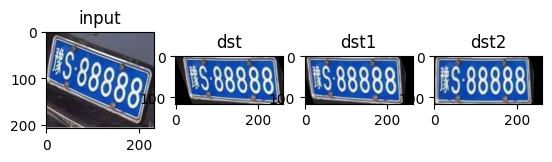

In [74]:
img = cv.imread(r"F:\machine\OpenCV\car3_plat.jpg",1)
h,w,_=img.shape
M = cv.getRotationMatrix2D(center=(0,0),angle=20, scale=1)
dst = cv.warpAffine(img,M,(w+30,w//2), borderValue=[0,0,0])
pts1 = np.float32([[15,0],[245,0],[250,115]])
pts2 = np.float32([[0,0],[230,0],[230,115]])
M = cv.getAffineTransform(pts1,pts2)
h,w,_=dst.shape
dst1 = cv.warpAffine(dst,M,(w,h))

pts1 = np.float32([[15,0],[245,0],[250,115],[34,100]])
pts2 = np.float32([[0,0],[230,0],[230,115],[0,115]])

M = cv.getPerspectiveTransform(pts1,pts2)
dst2 = cv.warpPerspective(dst,M,(w,h))

plt.subplot(141)
plt.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB))
plt.title("input")
plt.subplot(142)
plt.imshow(cv.cvtColor(dst,cv.COLOR_BGR2RGB))
plt.title("dst")
plt.subplot(143)
plt.imshow(cv.cvtColor(dst1,cv.COLOR_BGR2RGB))
plt.title("dst1")
plt.subplot(144)
plt.imshow(cv.cvtColor(dst2,cv.COLOR_BGR2RGB))
plt.title("dst2")

## 基于透视变换提取车牌

Text(0.5, 1.0, 'dst')

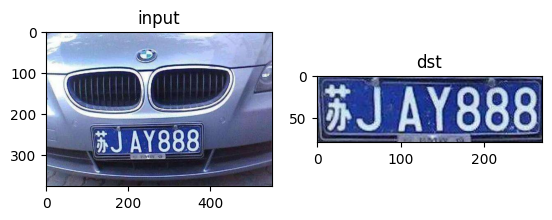

In [88]:
img = cv.imread(r"F:\machine\OpenCV\car.jpg",1)

pts1 = np.float32([[110,232],[380,223],[380,306],[115,309]])
pts2 = np.float32([[0,0],[270,0],[270,80],[0,80]])
# pts2 = np.float32([[100,100],[370,100],[370,180],[100,180]])

M = cv.getPerspectiveTransform(pts1,pts2)
dst = cv.warpPerspective(img,M,(270,80))
plt.subplot(121)
plt.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB))
plt.title("input")
plt.subplot(122)
plt.imshow(cv.cvtColor(dst,cv.COLOR_BGR2RGB))
plt.title("dst")

## 二值化操作

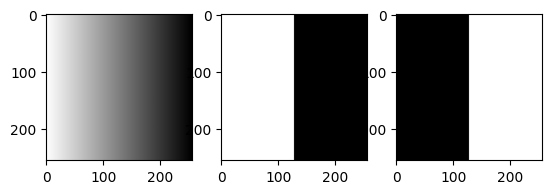

In [94]:
img = np.arange(255,-1,-1).reshape(1,-1)
for i in range(255):
    img = np.append(img,np.arange(255,-1,-1).reshape(1,-1),axis=0)
img = img.astype("uint8")

ret,thresh1 = cv.threshold(src=img, thresh=127, maxval=255, type=cv.THRESH_BINARY)
ret,thresh2 = cv.threshold(src=img, thresh=127, maxval=255, type=cv.THRESH_BINARY_INV)

plt.subplot(131)
plt.imshow(img/255.0,"gray")
plt.subplot(132)
plt.imshow(thresh1/255.0,"gray")

plt.subplot(133)
plt.imshow(thresh2/255.0,"gray")

plt.show()

## 图像滤波

### 图像模糊化

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

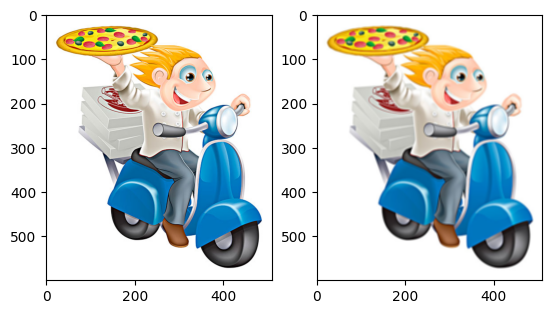

In [3]:
img1 = cv.imread(r"F:\machine\OpenCV\xiaoren.png",1)
kernel = np.ones((5,5),np.float32) / 25

# 第二个参数-1表示不限制超出边界（0,255），默认值即可
img2 = cv.filter2D(img1,-1,kernel)

plt.subplot(121)
plt.imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))
plt.show()

### 均值滤波

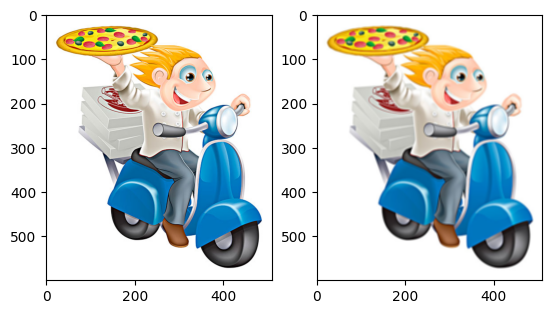

In [4]:
img1 = cv.imread(r"F:\machine\OpenCV\xiaoren.png",1)

img2 = cv.blur(img1, ksize=(5,5))

plt.subplot(121)
plt.imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))
plt.show()

### 高斯滤波

In [6]:
a = cv.getGaussianKernel(5,1,ktype=cv.CV_64F)
b = np.dot(a,a.T)
print(a)
print(b)

[[0.05448868]
 [0.24420134]
 [0.40261995]
 [0.24420134]
 [0.05448868]]
[[0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.02193823 0.09832033 0.16210282 0.09832033 0.02193823]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]]


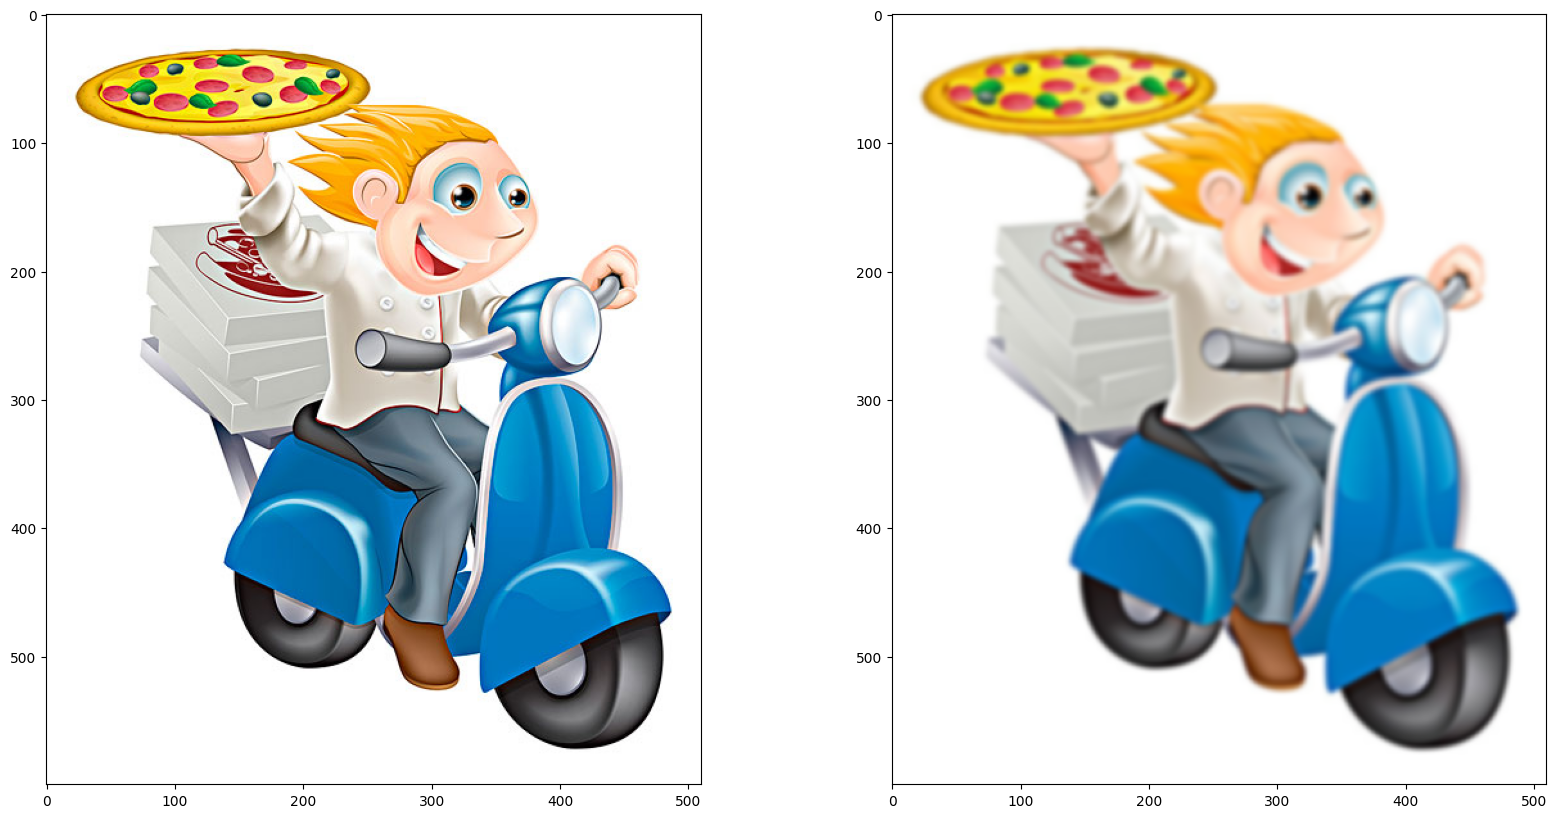

In [8]:
img1 = cv.imread(r"F:\machine\OpenCV\xiaoren.png",1)

img2 = cv.GaussianBlur(img1, ksize=(9,9),sigmaX=2.0,sigmaY=2.0)

plt.figure(figsize=(20,10))
plt.subplot(121)
plt.imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))
plt.show()

## 形态学变换

### 腐蚀

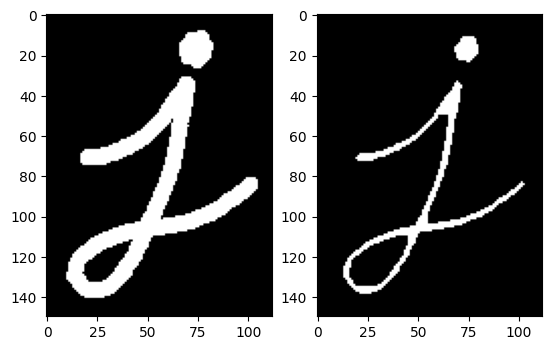

In [10]:
img = cv.imread(r"F:\machine\OpenCV\j.png",0)
kernel = np.ones((5,5),np.uint8)
dst = cv.erode(img,kernel,iterations=1,borderType=cv.BORDER_REFLECT)
plt.subplot(121)
plt.imshow(cv.cvtColor(img,cv.COLOR_GRAY2BGR))
plt.subplot(122)
plt.imshow(cv.cvtColor(dst,cv.COLOR_GRAY2BGR))
plt.show()

### 膨胀

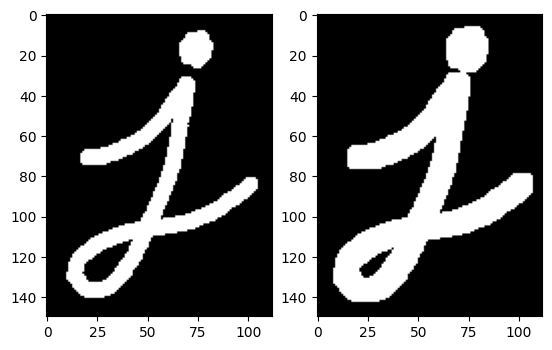

In [11]:
img = cv.imread(r"F:\machine\OpenCV\j.png",0)
kernel = np.ones((5,5),np.uint8)
dst = cv.dilate(img,kernel,iterations=1)
plt.subplot(121)
plt.imshow(cv.cvtColor(img,cv.COLOR_GRAY2BGR))
plt.subplot(122)
plt.imshow(cv.cvtColor(dst,cv.COLOR_GRAY2BGR))
plt.show()

### open

In [16]:
#加白色噪声
img = cv.imread(r"F:\machine\OpenCV\j.png",0)
h,w=img.shape
for i in range(100):
    x = np.random.randint(w)
    y = np.random.randint(h)
    img[y,x]=255


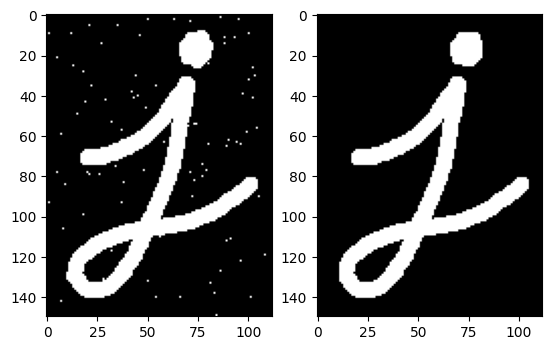

In [17]:
kernel = np.ones((5,5),np.uint8)
dst = cv.morphologyEx(img, op=cv.MORPH_OPEN,kernel=kernel,iterations=1)
plt.subplot(121)
plt.imshow(cv.cvtColor(img,cv.COLOR_GRAY2BGR))
plt.subplot(122)
plt.imshow(cv.cvtColor(dst,cv.COLOR_GRAY2BGR))
plt.show()

In [21]:
print(cv.CV_64F)

6


### Canny 

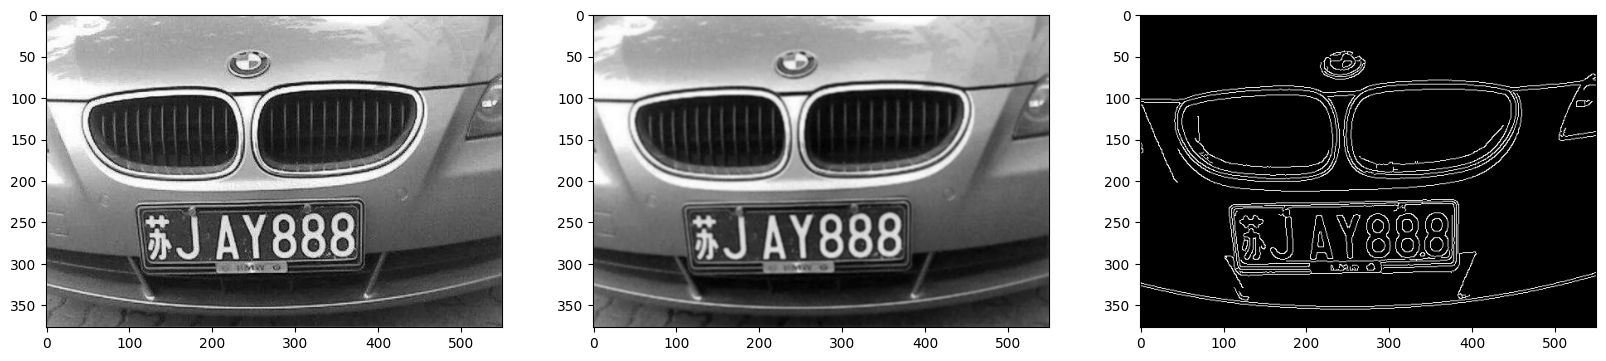

In [33]:
img = cv.imread(r"F:\machine\OpenCV\car.jpg",0)
blur = cv.GaussianBlur(img,(5,5),0)
edgs = cv.Canny(blur,threshold1=50,threshold2=250)
plt.figure(figsize=(20,10))
plt.subplot(131)
plt.imshow(img,cmap="gray")
plt.subplot(132)
plt.imshow(blur,cmap="gray")
plt.subplot(133)
plt.imshow(edgs,cmap="gray")
plt.show()

## 提取轮廓信息

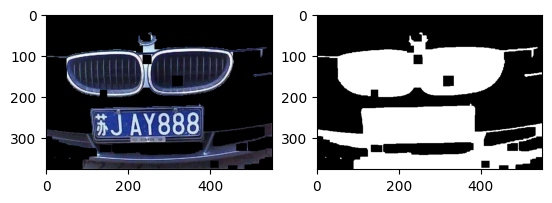

In [46]:
# 加载图像
img = cv.imread(r"F:\machine\OpenCV\car.jpg")

# 将图像转换为灰度图像
img1 = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 做一个图像反转(0 -> 255, 255 -> 0)
img1 = cv.bitwise_not(img1)

# 做一个二值化
ret, thresh = cv.threshold(img1, 200, 255, cv.THRESH_BINARY)

# 发现轮廓信息
# 第一个参数是原始图像，第二个参数是轮廓的检索模型，第三个参数是轮廓的近似方法
# 第一个返回值为轮廓，第三个返回值为层次信息
# CHAIN_APPROX_SIMPLE指的是对于一条直线上的点而言，仅仅保留端点信息, 
# 而CHAIN_APPROX_NONE保留所有点
# contours, hierarchy = cv.findContours(thresh, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
# contours, hierarchy = cv.findContours(thresh, cv.RETR_TREE, cv.CHAIN_APPROX_NONE)
contours, hierarchy = cv.findContours(thresh, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)

# 在图像中绘制图像
# 当contourIdx为-1的时候，表示绘制所有轮廓，当为大于等于0的时候，表示仅仅绘制某一个轮廓
# 这里的返回值img3和img是同一个对象，在当前版本中
# img3 = cv.drawContours(img, contours, contourIdx=-1, color=(0, 0, 255), thickness=2)
# max_idx = np.argmax([len(t) for t in contours])
# img3 = cv.drawContours(img, contours, contourIdx=max_idx, color=(0, 0, 255), thickness=2)

# 将轮廓当成边缘
mask = np.zeros_like(img)
cv.drawContours(mask, contours, contourIdx=-1, color=(255,255,255), thickness=2)

kernel = np.ones((5,5),np.uint8)
# 膨胀、腐蚀
mask=cv.dilate(mask,kernel,iterations=4)
mask=cv.erode(mask,kernel,iterations=4)

img = cv.bitwise_and(img,img,mask=mask[:,:,0])
plt.subplot(121)
plt.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(mask,cmap="gray")
plt.show()